In [1]:
import numpy as np
import jax.numpy as jnp
import matplotlib.pyplot as plt
import pyvista as pv
import nest_asyncio

nest_asyncio.apply()

pv.set_jupyter_backend('trame')

from pyvista.trame.jupyter import launch_server
await launch_server().ready

from Suspension.hardpoint_loader import load_suspension_params
from Suspension.jax_solvers import solve_and_measure_corner
from Suspension.visualizer import SuspensionVisualizer
from Suspension.jax_solvers import get_world_params
from Suspension.jax_solvers import solve_theta_for_ground

In [2]:
# # 1. Setup Parameters
# corner_name = "front_right"
# params = load_suspension_params("hardpoints.yaml", corner_name)

# # 2. Define the Range of Motion
# thetas = jnp.radians(jnp.linspace(-3, 3, 40)) 
# # thetas = [0.0, 0.2]
# fixed_steer = 0.0

# # 3. Initialize storage for results
# travel_mm = []
# caster_deg = []
# scrub_mm = []
# camber_deg = []
# toe_deg = []
# kpi_deg = []    
# mech_trail_mm = [] 

# # 4. Run the Sweep Loop
# for t in thetas:
#     metrics = solve_and_measure_corner(t, fixed_steer, params)
    
#     # Store the values (converting to readable units)
#     travel_mm.append(metrics["wheel_z"] * 1000)
#     caster_deg.append(jnp.degrees(metrics["caster"]))
#     scrub_mm.append(metrics["scrub_radius"] * 1000)
#     camber_deg.append(jnp.degrees(metrics["camber"]))
#     toe_deg.append(jnp.degrees(metrics["toe"]))
#     kpi_deg.append(jnp.degrees(metrics["kingpin_inc"]))
#     mech_trail_mm.append(metrics["mechanical_trail"] * 1000)

# # 5. Plotting (Expanded to 3x2 Grid)
# plt.figure(figsize=(14, 15))

# # Plot 1: Camber Curve
# plt.subplot(3, 2, 1)
# plt.plot(travel_mm, camber_deg, color='green', linewidth=2)
# plt.axhline(0, color='black', linewidth=0.8, alpha=0.5)
# plt.title("Wheel Travel vs. Camber")
# plt.xlabel("Wheel Z (mm)")
# plt.ylabel("Camber (deg)")
# plt.grid(True, linestyle='--', alpha=0.6)

# # Plot 2: Bump Steer (Toe)
# plt.subplot(3, 2, 2)
# plt.plot(travel_mm, toe_deg, color='purple', linewidth=2)
# plt.axhline(0, color='black', linewidth=0.8, alpha=0.5)
# plt.title("Wheel Travel vs. Toe (Bump Steer)")
# plt.xlabel("Wheel Z (mm)")
# plt.ylabel("Toe (deg)")
# plt.grid(True, linestyle='--', alpha=0.6)

# # Plot 3: Caster
# plt.subplot(3, 2, 3)
# plt.plot(travel_mm, caster_deg, color='blue', linewidth=2)
# plt.title("Wheel Travel vs. Caster")
# plt.xlabel("Wheel Z (mm)")
# plt.ylabel("Caster (deg)")
# plt.grid(True, linestyle='--', alpha=0.6)

# # Plot 4: Kingpin Inclination (KPI/SAI)
# plt.subplot(3, 2, 4)
# plt.plot(travel_mm, kpi_deg, color='darkorange', linewidth=2)
# plt.title("Wheel Travel vs. Kingpin Inclination")
# plt.xlabel("Wheel Z (mm)")
# plt.ylabel("KPI (deg)")
# plt.grid(True, linestyle='--', alpha=0.6)

# # Plot 5: Scrub Radius
# plt.subplot(3, 2, 5)
# plt.plot(travel_mm, scrub_mm, color='red', linewidth=2)
# plt.axhline(0, color='black', linewidth=0.8, alpha=0.5)
# plt.title("Wheel Travel vs. Scrub Radius")
# plt.xlabel("Wheel Z (mm)")
# plt.ylabel("Scrub Radius (mm)")
# plt.grid(True, linestyle='--', alpha=0.6)

# # Plot 6: Mechanical Trail
# plt.subplot(3, 2, 6)
# plt.plot(travel_mm, mech_trail_mm, color='brown', linewidth=2)
# plt.axhline(0, color='black', linewidth=0.8, alpha=0.5)
# plt.title("Wheel Travel vs. Mechanical Trail")
# plt.xlabel("Wheel Z (mm)")
# plt.ylabel("Mechanical Trail (mm)")
# plt.grid(True, linestyle='--', alpha=0.6)

# plt.tight_layout()
# plt.show()

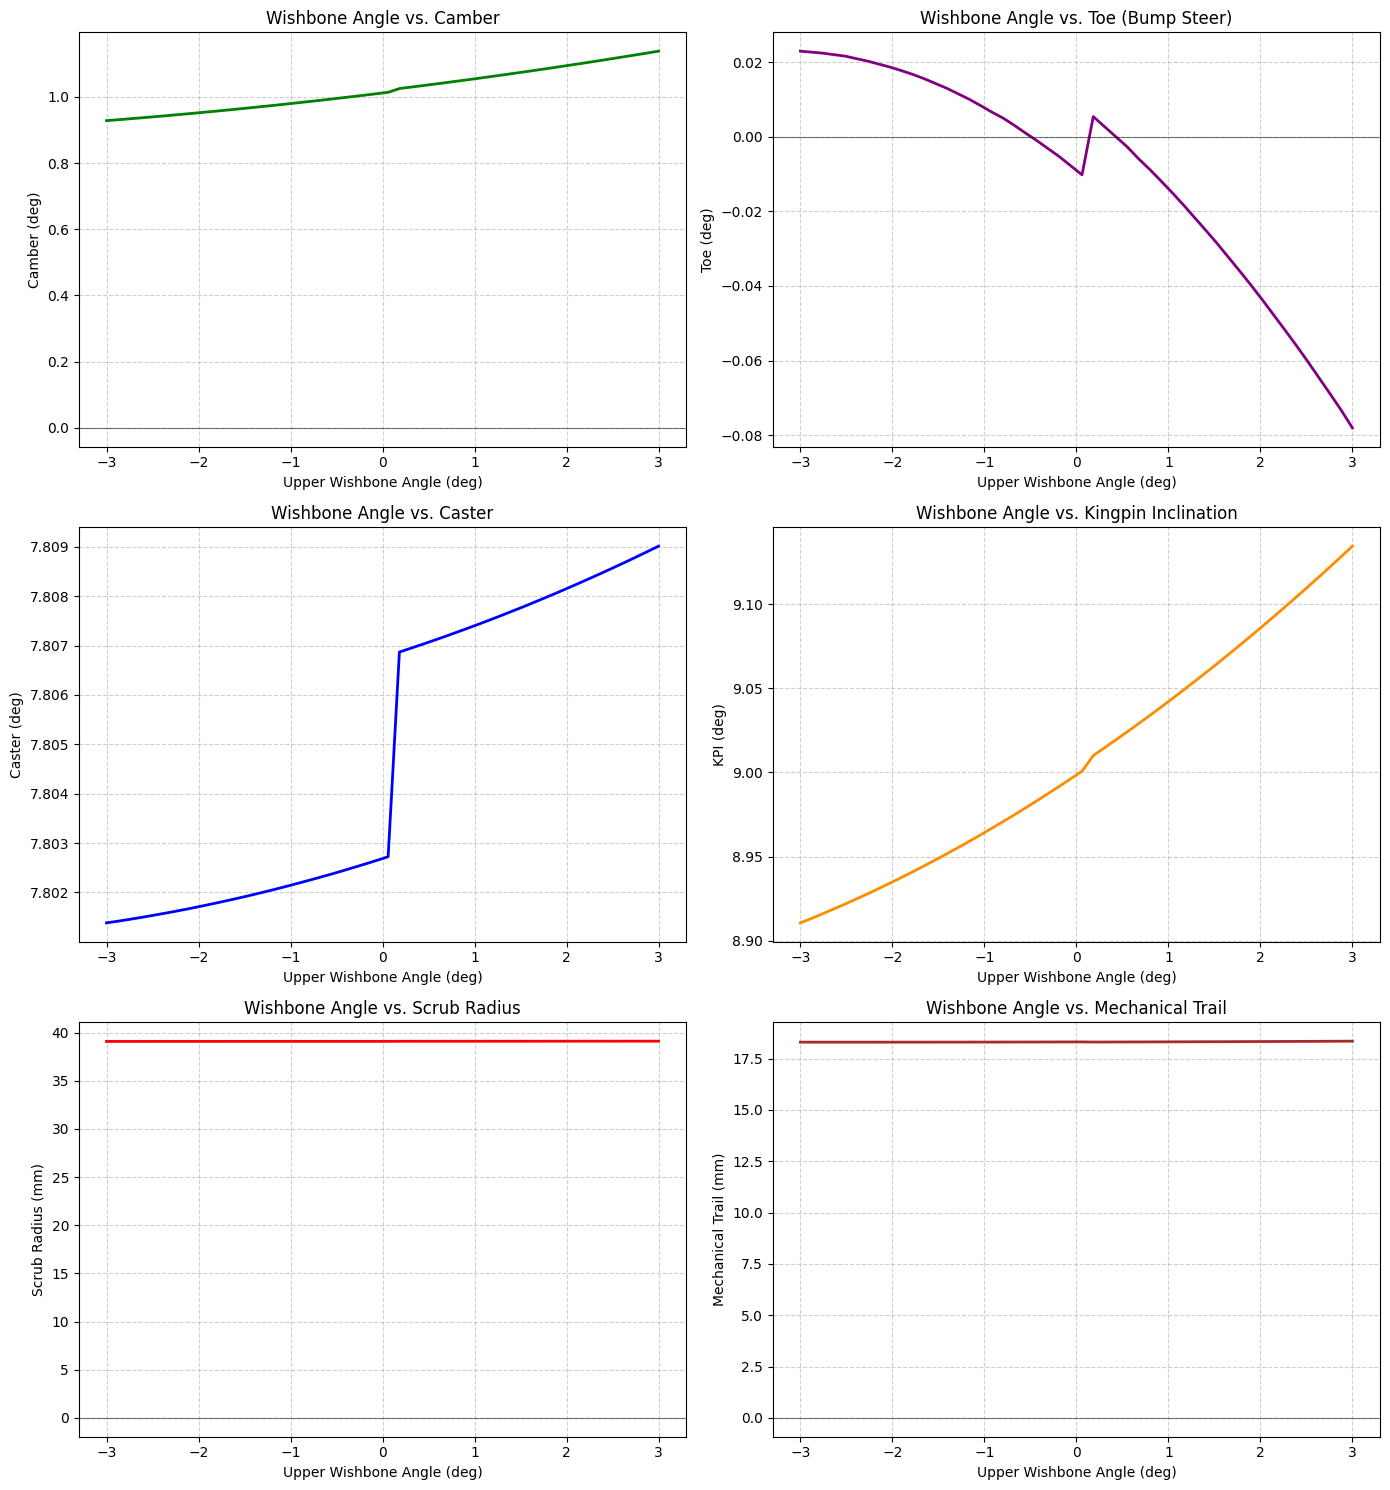

In [8]:
# 1. Setup Parameters
corner_name = "front_right"
params = load_suspension_params("hardpoints.yaml", corner_name)

# 2. Define the Range of Motion
thetas_rad = jnp.radians(jnp.linspace(-3.0, 3.0, 50)) # Slightly wider range for better curves
fixed_steer = 0.0

# 3. Initialize storage for results
theta_deg_axis = []
caster_deg = []
scrub_mm = []
camber_deg = []
toe_deg = []
kpi_deg = []    
mech_trail_mm = [] 

# 4. Run the Sweep Loop
for t in thetas_rad:
    metrics = solve_and_measure_corner(t, fixed_steer, params)
    
    # Store the values (converting to readable units)
    theta_deg_axis.append(jnp.degrees(t)) # X-axis in degrees
    caster_deg.append(jnp.degrees(metrics["caster"]))
    scrub_mm.append(metrics["scrub_radius"] * 1000)
    camber_deg.append(jnp.degrees(metrics["camber"]))
    toe_deg.append(jnp.degrees(metrics["toe"]))
    kpi_deg.append(jnp.degrees(metrics["kingpin_inc"]))
    mech_trail_mm.append(metrics["mechanical_trail"] * 1000)

# 5. Plotting (Expanded to 3x2 Grid)
plt.figure(figsize=(14, 15))
x_label = "Upper Wishbone Angle (deg)"

# Plot 1: Camber Curve
plt.subplot(3, 2, 1)
plt.plot(theta_deg_axis, camber_deg, color='green', linewidth=2)
plt.axhline(0, color='black', linewidth=0.8, alpha=0.5)
plt.title("Wishbone Angle vs. Camber")
plt.xlabel(x_label)
plt.ylabel("Camber (deg)")
plt.grid(True, linestyle='--', alpha=0.6)

# Plot 2: Bump Steer (Toe)
plt.subplot(3, 2, 2)
plt.plot(theta_deg_axis, toe_deg, color='purple', linewidth=2)
plt.axhline(0, color='black', linewidth=0.8, alpha=0.5)
plt.title("Wishbone Angle vs. Toe (Bump Steer)")
plt.xlabel(x_label)
plt.ylabel("Toe (deg)")
plt.grid(True, linestyle='--', alpha=0.6)

# Plot 3: Caster
plt.subplot(3, 2, 3)
plt.plot(theta_deg_axis, caster_deg, color='blue', linewidth=2)
plt.title("Wishbone Angle vs. Caster")
plt.xlabel(x_label)
plt.ylabel("Caster (deg)")
plt.grid(True, linestyle='--', alpha=0.6)

# Plot 4: Kingpin Inclination (KPI/SAI)
plt.subplot(3, 2, 4)
plt.plot(theta_deg_axis, kpi_deg, color='darkorange', linewidth=2)
plt.title("Wishbone Angle vs. Kingpin Inclination")
plt.xlabel(x_label)
plt.ylabel("KPI (deg)")
plt.grid(True, linestyle='--', alpha=0.6)

# Plot 5: Scrub Radius
plt.subplot(3, 2, 5)
plt.plot(theta_deg_axis, scrub_mm, color='red', linewidth=2)
plt.axhline(0, color='black', linewidth=0.8, alpha=0.5)
plt.title("Wishbone Angle vs. Scrub Radius")
plt.xlabel(x_label)
plt.ylabel("Scrub Radius (mm)")
plt.grid(True, linestyle='--', alpha=0.6)

# Plot 6: Mechanical Trail
plt.subplot(3, 2, 6)
plt.plot(theta_deg_axis, mech_trail_mm, color='brown', linewidth=2)
plt.axhline(0, color='black', linewidth=0.8, alpha=0.5)
plt.title("Wishbone Angle vs. Mechanical Trail")
plt.xlabel(x_label)
plt.ylabel("Mechanical Trail (mm)")
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

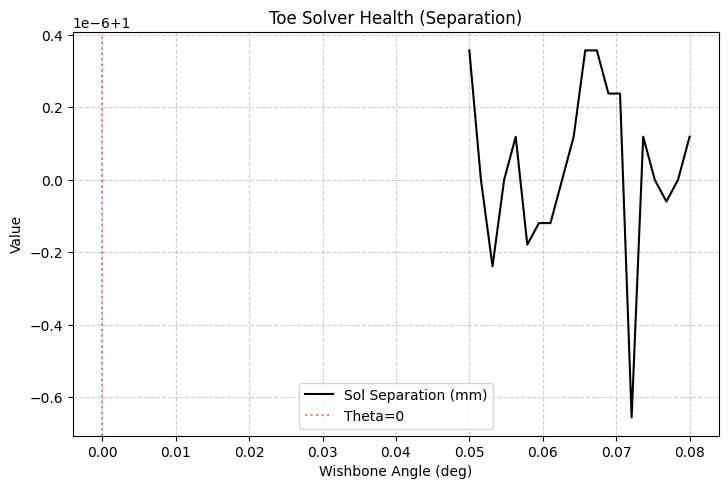

In [4]:
# --- Initialize storage ---
# ... (your existing lists) ...
toe_separations = []
toe_z_sq_vals = []
determinant_vals = []
trace_vals = []

# --- Run the Sweep ---
for t in thetas_rad:
    # Note: You'll need to modify solve_and_measure_corner to return these 
    # OR call solve_toe_link_jax manually here for diagnostics
    metrics = solve_and_measure_corner(t, fixed_steer, params)
    
    # Assuming you updated solve_and_measure to return these:
    # toe_separations.append(metrics["toe_separation"] * 1000) # mm
    # toe_z_sq_vals.append(metrics["toe_z_sq"])
    determinant_vals.append(metrics["determinant"])
    

    
    # ... (rest of your storage) ...

# --- Plotting (Adding the Delta Plot) ---
plt.figure(figsize=(14, 18))


# Plot 7: Toe Solution Delta (Diagnostic)
plt.subplot(4, 2, 7)
plt.plot(theta_deg_axis, determinant_vals, color='black', label="Sol Separation (mm)")
# plt.plot(theta_deg_axis, [z * 1000 for z in toe_z_sq_vals], '--', label="z_sq (scaled)", alpha=0.5)
plt.axvline(0, color='red', linestyle=':', alpha=0.5, label="Theta=0")
plt.title("Toe Solver Health (Separation)")
plt.xlabel("Wishbone Angle (deg)")
plt.ylabel("Value")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

In [5]:
# 1. Setup the parameters (All 4 corners)
params_all = {
    "fr": load_suspension_params("hardpoints.yaml", "front_right"),
    "fl": load_suspension_params("hardpoints.yaml", "front_left"),
    "rr": load_suspension_params("hardpoints.yaml", "rear_right"),
    "rl": load_suspension_params("hardpoints.yaml", "rear_left")
}

# 2. Initialize Visualizer (using FR as base)
viz = SuspensionVisualizer(params_all["fr"])
viz.add_ground_plane()

# 3. Build Chassis and 4. Solve States
steer_val = 0.0 # m
thetas = jnp.deg2rad(0.0642)
initial_states = {}

for name, p in params_all.items():
    # Add static chassis points with a suffix
    viz.add_chassis_points(p, suffix=name)
    
    # Solve kinematics
    state = solve_and_measure_corner(thetas, steer_val, p)
    initial_states[name] = state
    
    # Update the rack position immediately after creating it
    viz.update_rack_displacement(f"rack_mesh_{name}", p['rack_origin'], steer_val)

    # Setup ICs and ISA
    viz.setup_instant_center(state["instant_roll_center"], state["contact_patch"], f"ic_{name}")
    viz.setup_isa_axis(state["isa_q"], state["isa_s"], f"isa_{name}")

# 5. Setup the moving parts for all 4 corners
for name, p in params_all.items():
    state = initial_states[name]
    
    u_color = "royalblue" if "f" in name else "darkcyan"
    l_color = "firebrick" if "f" in name else "chocolate"

    # A-Arms
    viz.setup_a_arms(p["u_front"], p["u_rear"], state["upper_bj"], u_color, f"u_arm_{name}")
    viz.setup_a_arms(p["l_front"], p["l_rear"], state["lower_bj"], l_color, f"l_arm_{name}")

    # Hardpoints
    viz.setup_hardpoints(state["upper_bj"], f"UBJ_{name}")
    viz.setup_hardpoints(state["lower_bj"], f"LBJ_{name}")
    viz.setup_hardpoints(state["toe_link"], f"TOE_{name}")

    # Upright
    viz.setup_upright(state["upper_bj"], state["lower_bj"], state["toe_link"], "green", f"upright_{name}")

    steered_rack_pos = p["rack_origin"] + np.array([0, steer_val, 0])
    viz.setup_tie_rod(steered_rack_pos, state["toe_link"], f"tie_rod_{name}")
    
    # Wheel
    viz.setup_wheel_disc(state["wheel_center"], state["axle_dir"], p["wheel_radius"], 0.2, f"wheel_{name}")

# 6. Preview the full car
viz.plotter.reset_camera()
viz.plotter.camera_position = [(5, -5, 2), (1, 0, 0.5), (0, 0, 1)]
viz.plotter.show()

Widget(value='<iframe src="http://localhost:50754/index.html?ui=P_0x1465a86d0_0&reconnect=auto" class="pyvista…

In [6]:
# --- INPUTS ---
chassis_pose = {
    'xyz': [0.0, 0.0, 0.0],
    'roll': jnp.deg2rad(0.0),  
    'pitch': jnp.deg2rad(0.0)
}
steer_val = 0.0 #m

# --- PROCESSING ---
initial_states = {}
world_params_all = {}

for name, local_p in params_all.items():
    world_p = get_world_params(local_p, chassis_pose['xyz'], chassis_pose['roll'], chassis_pose['pitch'])
    
    try:
        # Solve for the compression angle
        ground_theta = solve_theta_for_ground(steer_val, world_p)
        state_jax = solve_and_measure_corner(ground_theta, steer_val, world_p)
        
        # Convert everything to standard numpy and check for validity
        state_np = {}
        for k, v in state_jax.items():
            val = np.array(v)
            if np.any(np.isnan(val)):
                print(f"Warning: {name} {k} contains NaN. Using zeros.")
                val = np.nan_to_num(val)
            state_np[k] = val
            
        if np.linalg.norm(state_np["axle_dir"]) < 1e-6:
            state_np["axle_dir"] = np.array([0.0, 1.0, 0.0])

        initial_states[name] = state_np
        world_params_all[name] = world_p
        
    except Exception as e:
        print(f"Solver failed for corner {name}: {e}")

# --- VISUALIZATION ---
viz = SuspensionVisualizer(params_all["fr"])
viz.add_ground_plane()

# 1. Draw the Chassis Skeleton first
viz.add_chassis_skeleton(world_params_all)

# 2. Draw the individual corners
for name, p_world in world_params_all.items():
    state = initial_states[name]
    p_local = params_all[name]
    
    # Existing component setups
    u_color = "royalblue" if "f" in name else "darkcyan"
    l_color = "firebrick" if "f" in name else "chocolate"

    viz.setup_a_arms(p_world["u_front"], p_world["u_rear"], state["upper_bj"], u_color, f"u_arm_{name}")
    viz.setup_a_arms(p_world["l_front"], p_world["l_rear"], state["lower_bj"], l_color, f"l_arm_{name}")
    viz.setup_upright(state["upper_bj"], state["lower_bj"], state["toe_link"], "green", f"upright_{name}")
    
    # Tie Rod & Wheel...
    actual_steer = steer_val * p_local["side_sign"]
    steered_rack_pos = p_world["rack_origin"] + jnp.array([0, actual_steer, 0])
    viz.setup_tie_rod(steered_rack_pos, state["toe_link"], f"tie_rod_{name}")
    viz.setup_wheel_disc(state["wheel_center"], state["axle_dir"], p_local["wheel_radius"], 0.2, f"wheel_{name}")

viz.plotter.show()

Widget(value='<iframe src="http://localhost:50754/index.html?ui=P_0x1466946d0_1&reconnect=auto" class="pyvista…

In [7]:
# # 1. Setup the Scene
# viz = SuspensionVisualizer(params_r)
# viz.add_ground_plane()
# viz.add_chassis_points(params_r)
# viz.add_chassis_points(params_l)

# # Initialize all meshes at static height (theta=0)
# for side, p, state in [("r", params_r, initial_state_r), ("l", params_l, initial_state_l)]:
#     viz.setup_a_arms(p["u_front"], p["u_rear"], state["upper_bj"], "royalblue", f"u_arm_{side}")
#     viz.setup_a_arms(p["l_front"], p["l_rear"], state["lower_bj"], "firebrick", f"l_arm_{side}")
#     viz.setup_hardpoints(state["upper_bj"], f"UBJ_{side}")
#     viz.setup_hardpoints(state["lower_bj"], f"LBJ_{side}")
#     viz.setup_hardpoints(state["toe_link"], f"TOE_{side}")
#     viz.setup_upright(state["upper_bj"], state["lower_bj"], state["toe_link"], "green", f"upright_{side}")
#     viz.setup_tie_rod(p["rack_origin"], state["toe_link"], f"tie_rod_{side}")
#     viz.setup_wheel_disc(state["wheel_center"], state["axle_dir"], p["wheel_radius"], 0.2, f"wheel_{side}")

# # 2. Define Animation Parameters
# frames = 60
# # Create a sine wave for theta: -10 degrees to +10 degrees
# theta_sweep = jnp.radians(10) * jnp.sin(jnp.linspace(0, 2 * jnp.pi, frames))

# # 3. Run the Animation Loop
# filename = "suspension_animation.mp4"
# viz.plotter.open_movie(filename)

# for t in theta_sweep:
#     # Solve new states for both sides
#     state_r = solve_corner_jax(t, 0.0, params_r)
#     state_l = solve_corner_jax(t, 0.0, params_l)
    
#     for side, p, state in [("r", params_r, state_r), ("l", params_l, state_l)]:
#         # Update A-Arms
#         viz.update_wishbone(f"u_arm_{side}", p["u_front"], p["u_rear"], state["upper_bj"])
#         viz.update_wishbone(f"l_arm_{side}", p["l_front"], p["l_rear"], state["lower_bj"])
        
#         # Update Upright and Hardpoints
#         viz.update_upright(f"upright_{side}", state["upper_bj"], state["lower_bj"], state["toe_link"])
#         viz.update_hardpoint(f"UBJ_{side}", state["upper_bj"])
#         viz.update_hardpoint(f"LBJ_{side}", state["lower_bj"])
#         viz.update_hardpoint(f"TOE_{side}", state["toe_link"])
        
#         # Update Tie Rod and Wheel
#         viz.update_tie_rod(f"tie_rod_{side}", p["rack_origin"], state["toe_link"])
#         viz.update_wheel(f"wheel_{side}", state["wheel_center"], state["axle_dir"], p["wheel_radius"], 0.2)
    
#     viz.plotter.write_frame()

# viz.plotter.close()
# print(f"Animation saved as {filename}")